# EDA of Google Playstore Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

In [3]:
df = pd.read_csv("googleplaystore_cleanedd.csv")
df.head(2)

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10840 non-null  int64  
 1   App             10840 non-null  object 
 2   Category        10840 non-null  object 
 3   Rating          9366 non-null   float64
 4   Reviews         10840 non-null  int64  
 5   Size            9145 non-null   float64
 6   Installs        10840 non-null  int64  
 7   Type            10839 non-null  object 
 8   Price           10840 non-null  float64
 9   Content Rating  10840 non-null  object 
 10  Genres          10840 non-null  object 
 11  Last Updated    10840 non-null  object 
 12  Current Ver     10832 non-null  object 
 13  Android Ver     10838 non-null  object 
 14  Day             10840 non-null  int64  
 15  Month           10840 non-null  int64  
 16  Year            10840 non-null  int64  
dtypes: float64(3), int64(6), object

In [5]:
df.describe()

,Unnamed: 0,Rating,Reviews,Size,Installs,Price,Day,Month,Year
count,10840.000000,9366.000000,1.084000e+04,9145.000000,1.084000e+04,10840.000000,10840.000000,10840.000000,10840.000000
mean,5419.533948,4.191757,4.441529e+05,19579.419913,1.546434e+07,1.027368,15.609041,6.422325,2017.399723
std,3129.439605,0.515219,2.927761e+06,24042.062020,8.502936e+07,15.949703,9.561621,2.578388,1.100914
min,0.000000,1.000000,0.000000e+00,1.000000,0.000000e+00,0.000000,1.000000,1.000000,2010.000000
25%,2709.750000,4.000000,3.800000e+01,5.600000,1.000000e+03,0.000000,6.000000,5.000000,2017.000000
50%,5419.500000,4.300000,2.094000e+03,13000.000000,1.000000e+05,0.000000,16.000000,7.000000,2018.000000
75%,8129.250000,4.500000,5.477550e+04,30000.000000,5.000000e+06,0.000000,24.000000,8.000000,2018.000000
max,10840.000000,5.000000,7.815831e+07,100000.000000,1.000000e+09,400.000000,31.000000,12.000000,2018.000000


In [6]:
df.head(3)

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018


In [8]:
df[df.duplicated('App')].shape

(1181, 17)

### Obsevation
The dataset has duplicate values.

In [9]:
dfc = df.copy()

In [24]:
dfc.drop('Unnamed: 0', axis = 1, inplace = True)

In [25]:
dfc = dfc.drop_duplicates(subset=['App'], keep='first')

In [26]:
dfc.shape

(9659, 16)

In [28]:
numeric_features = [feature for feature in dfc.columns if dfc[feature].dtype != 'O']
categorical_features = [feature for feature in dfc.columns if dfc[feature].dtype == 'O']


In [29]:
# Printing the columns.
print('We have {} numerical features: {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} numerical features: {}'.format(len(categorical_features), categorical_features))

We have 8 numerical features: ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Day', 'Month', 'Year']

We have 8 numerical features: ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [17]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 10839
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   int64  
 7   Type            9658 non-null   object 
 8   Price           9659 non-null   float64
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
 14  Day             9659 non-null   int64  
 15  Month           9659 non-null   int64  
 16  Year            9659 non-null   int64  
dtypes: float64(3), int64(6), object(8)
me

Propotion of count data on categorical columns

In [43]:
for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)
    print('-----------------------------------------------------------')

# Normalize: This instead of giving in the form of numbers it will give us in the from as percentage. That's why we multiply with 100.

App
ROBLOX                                                0.083026
CBS Sports App - Scores, News, Stats & Watch Live     0.073801
ESPN                                                  0.064576
Duolingo: Learn Languages Free                        0.064576
Candy Crush Saga                                      0.064576
                                                        ...   
Meet U - Get Friends for Snapchat, Kik & Instagram    0.009225
U-Report                                              0.009225
U of I Community Credit Union                         0.009225
Waiting For U Launcher Theme                          0.009225
iHoroscope - 2018 Daily Horoscope & Astrology         0.009225
Name: proportion, Length: 9659, dtype: float64
-----------------------------------------------------------
Category
FAMILY                 18.191882
GAME                   10.553506
TOOLS                   7.776753
MEDICAL                 4.271218
BUSINESS                4.243542
PRODUCTIVITY          

Proportion of count data on categorical data.

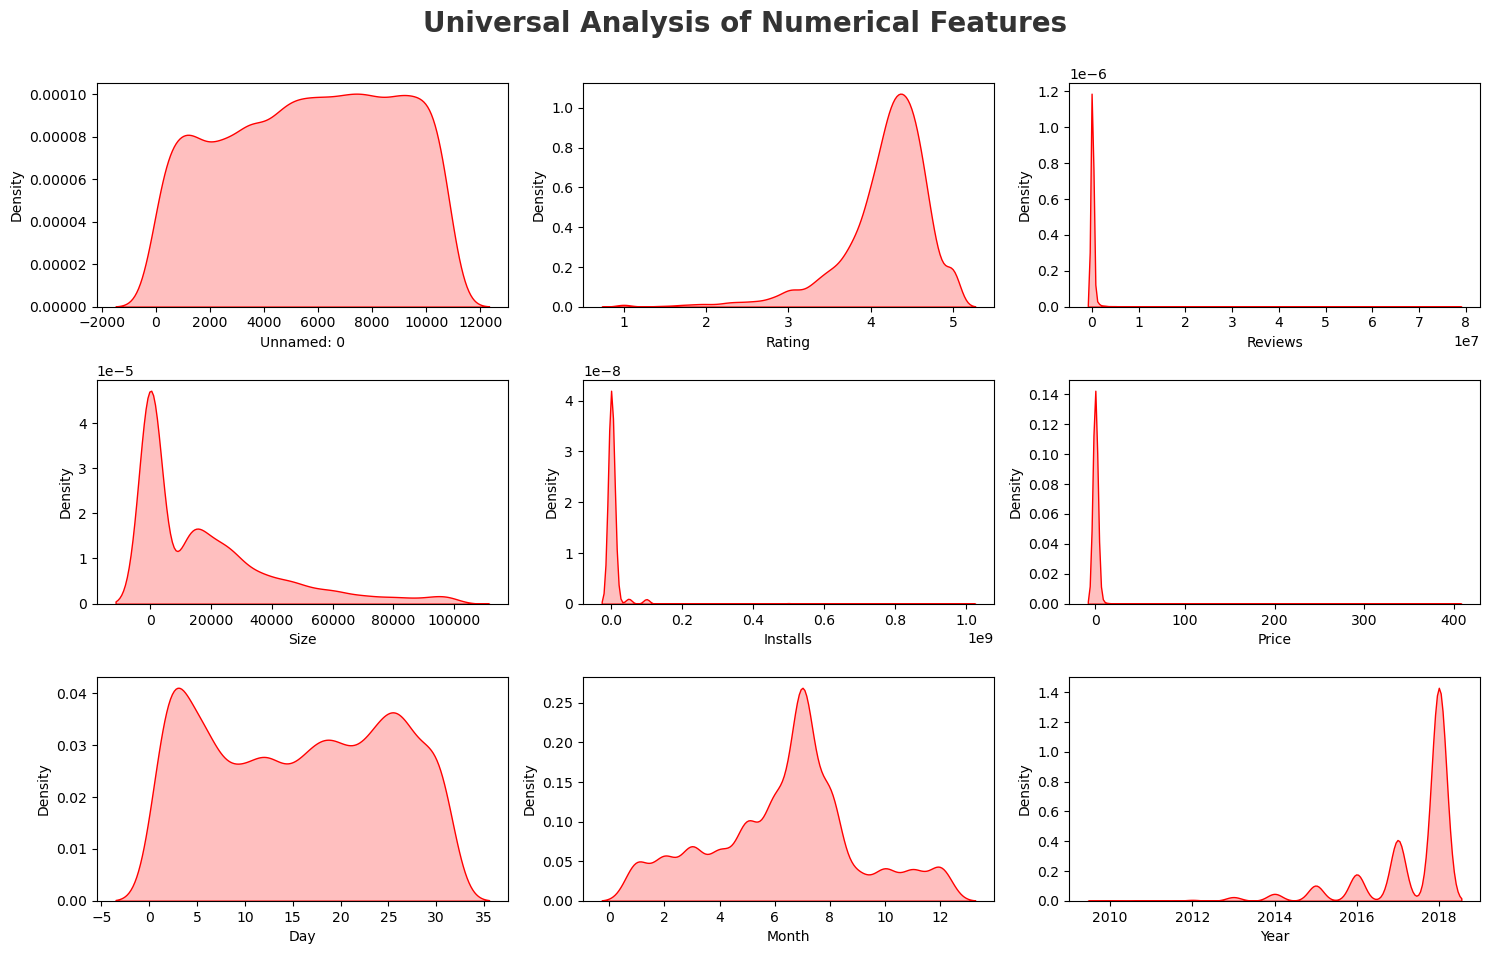

In [ ]:
plt.figure(figsize=(15,15))
plt.suptitle('Universal Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=dfc[numeric_features[i]], shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

## Observations from the abovw plots:
- Density and Year are Right-Skewed.
- Reviews, Price, Size and Installs are Left-Skewed.

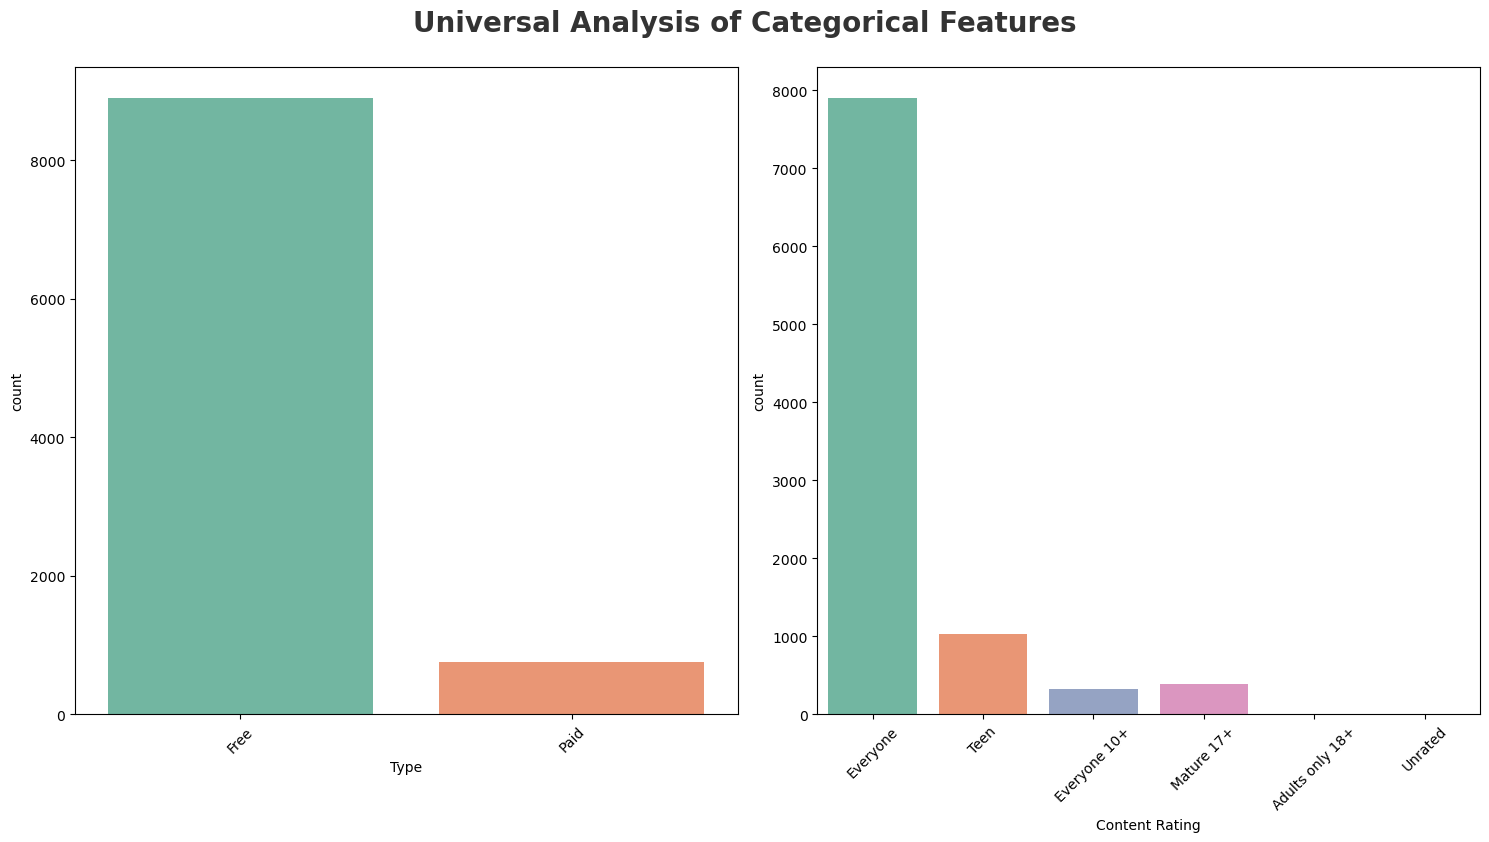

In [45]:
plt.figure(figsize=(15,15))
plt.suptitle('Universal Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = ['Type', 'Content Rating']

for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=dfc[category[i]], palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

## Which is the most popular app category?

In [46]:
dfc.head(2)

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


<Axes: ylabel='count'>

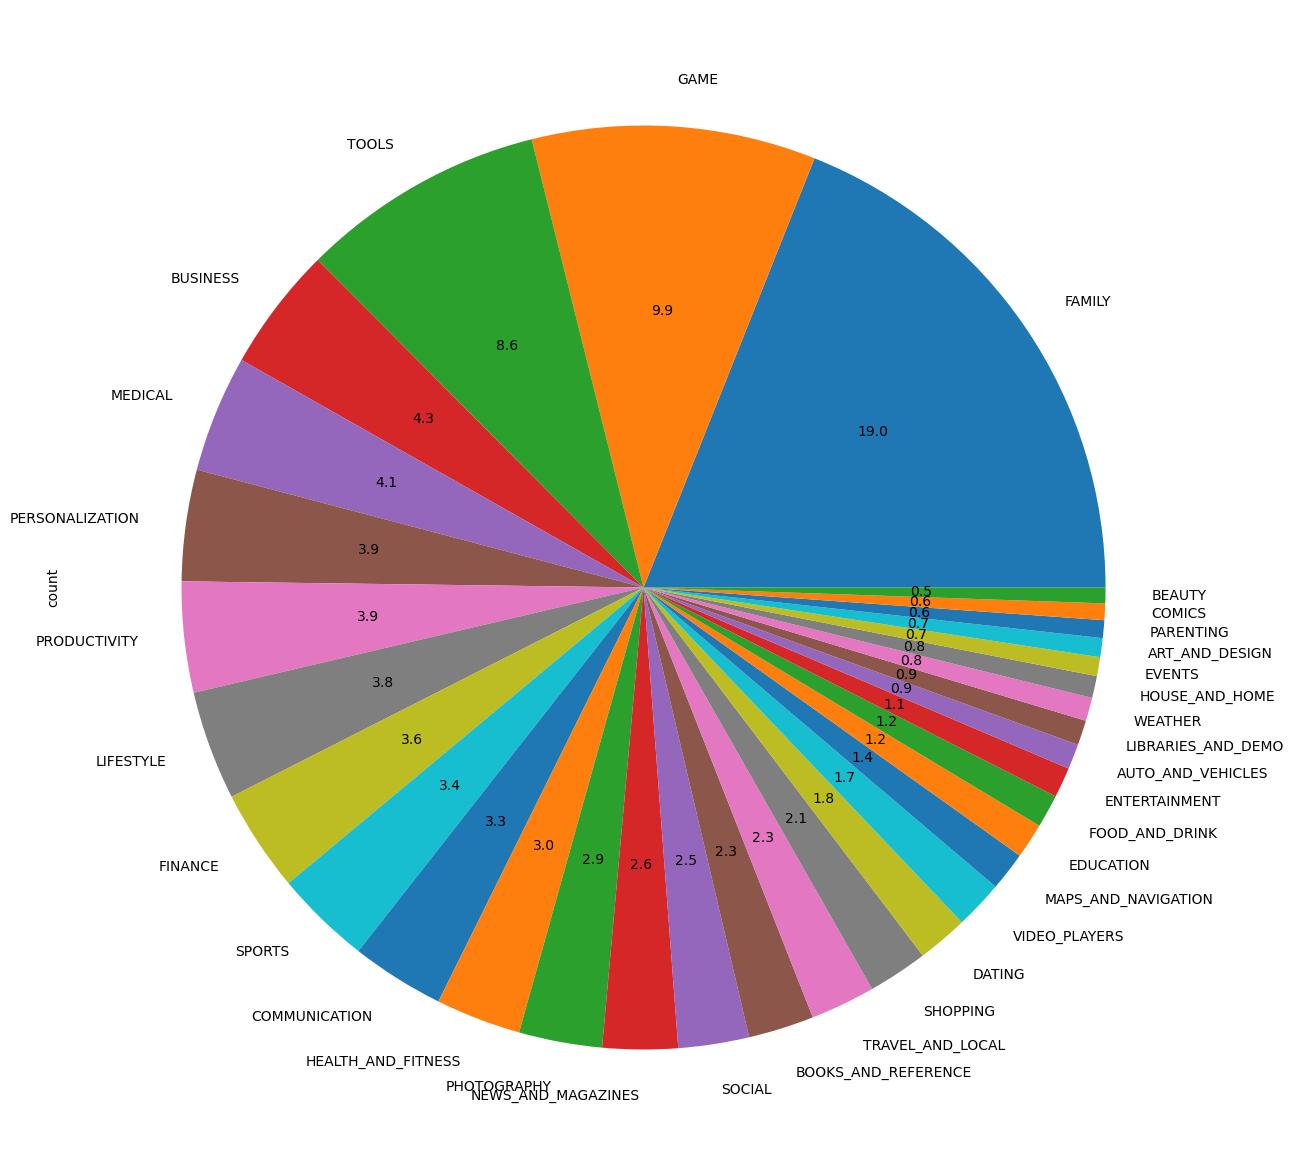

In [48]:
dfc['Category'].value_counts().plot.pie(y=df['Category'], figsize=(15,15), autopct = '%1.1f')

## Observation
1. There are more kinds of apps in playstore which are under category of family, games and tools.
2. Beauty, comics, arts and weather kinds of apps are very less in playstore.

In [52]:
# Top 10 App Categories

category = pd.DataFrame(df['Category'].value_counts())
category.rename(columns = {'Category':'Count'}, inplace=True)

In [53]:
category

,count
Category,
FAMILY,1972
GAME,1144
TOOLS,843
MEDICAL,463
BUSINESS,460
PRODUCTIVITY,424
PERSONALIZATION,392
COMMUNICATION,387
SPORTS,384


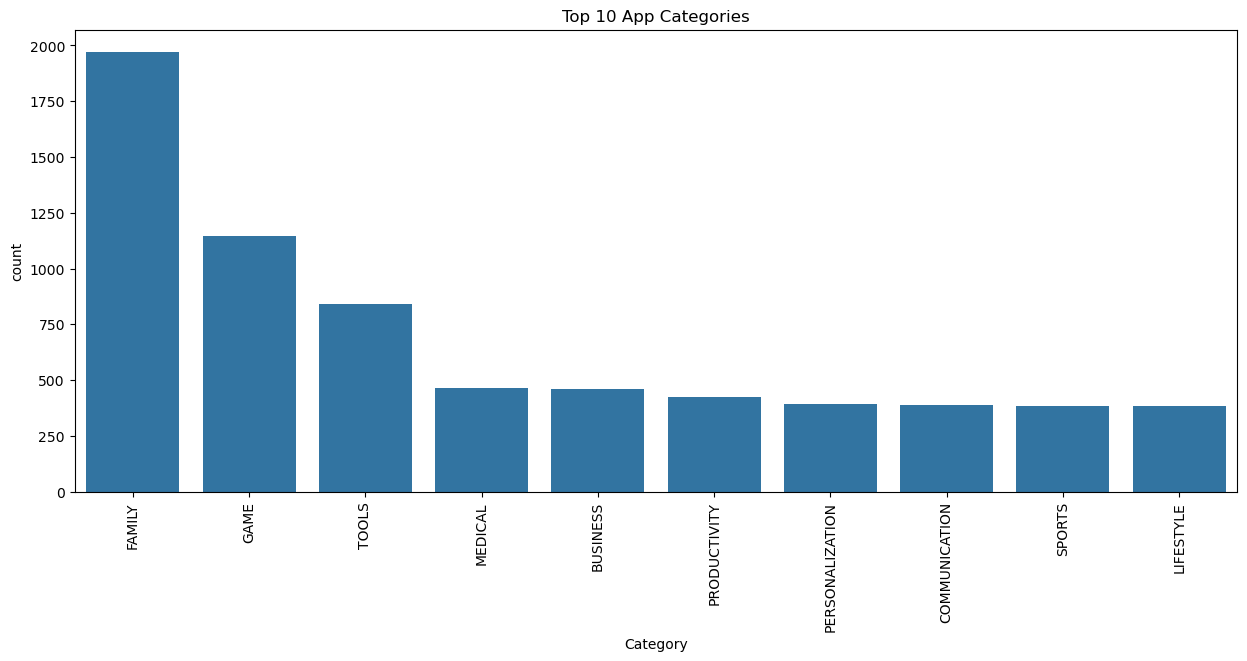

In [59]:
plt.figure(figsize=(15,6))
sns.barplot(x=category.index[:10], y='count', data = category[:10])
plt.title('Top 10 App Categories')
plt.xticks(rotation=90)
plt.show()